# Validation of Single-Path Sampling via Quantum Teleportation Protocol

This notebook validates single-path dynamic simulation by matching sampled final states against analytically known branch states, then comparing empirical branch frequencies to analytical targets.

Experiments included:
- Teleportation (4 branch states, uniform target).
- Teleportation with Final Bob Measurement (8 branch states)


In [1]:
from pathlib import Path
import sys
from itertools import product
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib
from matplotlib.backends.backend_pgf import FigureCanvasPgf

CANDIDATES = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
REPO_ROOT = None
for candidate in CANDIDATES:
    if (candidate / "src").exists():
        REPO_ROOT = candidate.resolve()
        break
if REPO_ROOT is None:
    raise RuntimeError("Could not locate repository root containing 'src'.")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

matplotlib.backend_bases.register_backend("pgf", FigureCanvasPgf)

from src.circuit_ir import CircuitIR
from src.simulation import DMRG_dynamic_single_path_from_circuit_ir


In [12]:
def normalize_state(state):
    psi = np.asarray(state, dtype=complex).reshape(-1)
    norm = float(np.linalg.norm(psi))
    if norm <= 0.0:
        raise ValueError("Encountered zero-norm state.")
    return psi / norm


def state_fidelity(psi, phi):
    psi_n = normalize_state(psi)
    phi_n = normalize_state(phi)
    return float(np.abs(np.vdot(phi_n, psi_n)) ** 2)


def tvd(empirical_probs, target_probs):
    return 0.5 * sum(abs(empirical_probs[k] - target_probs[k]) for k in target_probs.keys())


def run_single_path_state_once(circuit_ir, chunk_size, no_sweeps, bond_dims, network_structure, network_type, seed):
    _, state = DMRG_dynamic_single_path_from_circuit_ir(
        chunk_size=chunk_size,
        no_sweeps=no_sweeps,
        bond_dims=bond_dims,
        network_structure=network_structure,
        circuit_ir=circuit_ir,
        network_type=network_type,
        seed=seed,
        return_state=True,
    )
    return normalize_state(state)


def classify_state_against_targets(state, target_states):
    best_label = None
    best_fid = -1.0
    for label, target in target_states.items():
        fid = state_fidelity(state, target)
        if fid > best_fid:
            best_fid = fid
            best_label = label
    return best_label, best_fid


def estimate_state_label_distribution(
    circuit_ir,
    n_runs,
    target_states,
    base_seed,
    chunk_size,
    no_sweeps,
    bond_dims,
    network_structure,
    network_type,
    min_fidelity_threshold=0.999999,
):
    counts = {k: 0 for k in target_states.keys()}
    matched_fidelities = []
    rng = np.random.default_rng(base_seed)

    for _ in range(n_runs):
        seed = int(rng.integers(0, 2**32 - 1, dtype=np.uint32))
        state = run_single_path_state_once(
            circuit_ir=circuit_ir,
            chunk_size=chunk_size,
            no_sweeps=no_sweeps,
            bond_dims=bond_dims,
            network_structure=network_structure,
            network_type=network_type,
            seed=seed,
        )
        label, fid = classify_state_against_targets(state, target_states)
        if fid < min_fidelity_threshold:
            raise RuntimeError(f"State matching fidelity below threshold: {fid:.8f}")
        counts[label] += 1
        matched_fidelities.append(fid)

    probs = {k: v / float(n_runs) for k, v in counts.items()}
    return probs, float(np.mean(matched_fidelities)), float(np.min(matched_fidelities))


def run_convergence_experiment_by_state(
    circuit_ir,
    target_probs,
    target_states,
    N_values,
    num_repeats,
    chunk_size,
    no_sweeps,
    bond_dims,
    network_structure,
    network_type,
    master_seed,
):
    rng = np.random.default_rng(master_seed)
    rows = []

    for N in N_values:
        for repeat_idx in range(num_repeats):
            rep_seed = int(rng.integers(0, 2**32 - 1, dtype=np.uint32))
            probs, mean_fid, min_fid = estimate_state_label_distribution(
                circuit_ir=circuit_ir,
                n_runs=N,
                target_states=target_states,
                base_seed=rep_seed,
                chunk_size=chunk_size,
                no_sweeps=no_sweeps,
                bond_dims=bond_dims,
                network_structure=network_structure,
                network_type=network_type,
            )
            row = {
                "N": int(N),
                "repeat": int(repeat_idx),
                "tvd": float(tvd(probs, target_probs)),
                "mean_match_fidelity": mean_fid,
                "min_match_fidelity": min_fid,
            }
            for key, value in probs.items():
                row[f"p_{key}"] = float(value)
            rows.append(row)

    return rows


def summarize_tvd(rows, N_values):
    means, stds = [], []
    for N in N_values:
        vals = [r["tvd"] for r in rows if r["N"] == N]
        means.append(float(np.mean(vals)))
        stds.append(float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0)
    return np.array(means, dtype=float), np.array(stds, dtype=float)


def save_tvd_plot(rows, N_values, num_repeats, pgf_path):
    means, stds = summarize_tvd(rows, N_values)

    fig, ax = plt.subplots(figsize=(6, 4))
    font_size_tick = 20
    font_size_label = 20
    ax.tick_params(axis="both", which="major", labelsize=font_size_tick)
    ax.errorbar(
        N_values,
        means,
        yerr=stds,
        fmt="o-",
        capsize=4,
        linewidth=3,
        markersize=7,
        label=f"mean ± std ({num_repeats} repeats)",
    )

    ax.set_xscale("log", base=2)
    ax.set_xticks(N_values)
    ax.get_xaxis().set_major_formatter(mticker.ScalarFormatter())

    ax.set_xlabel("Number of runs", fontsize=font_size_label)
    ax.set_ylabel("TVD to exp. path distr.", fontsize=font_size_label)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=20)
    fig.tight_layout()

    pgf_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(pgf_path, format="pgf", bbox_inches="tight")
    return means, stds


In [3]:
# Shared experiment settings
N_VALUES = [2, 4, 8, 16, 32]
NUM_REPEATS = 10
CHUNK_SIZE = 20
NO_SWEEPS = 2

NETWORK_TYPE = "mps"
bond_dims = [2, 2]
NETWORK_STRUCTURE = [1, 3]

FIG_DIR = REPO_ROOT / "notebooks" / "figures"


## 1) Teleportation without Final Bob Measurement (4 branch states)

In [4]:
def build_dynamic_teleportation_ir(theta, phi):
    ir = CircuitIR(no_qubits=3, no_clbits=2)

    ir.add_operation("u", [0], params=[theta, phi, 0.0])
    ir.add_operation("h", [1])
    ir.add_operation("cx", [1, 2])
    ir.add_operation("cx", [0, 1])
    ir.add_operation("h", [0])
    ir.add_operation("measure", [0], clbits=[0])
    ir.add_operation("measure", [1], clbits=[1])
    ir.add_operation("x", [2], condition={"kind": "clbit_eq", "clbit": 1, "value": 1})
    ir.add_operation("z", [2], condition={"kind": "clbit_eq", "clbit": 0, "value": 1})
    return ir


def teleportation_target_states(theta, phi):
    alpha = np.cos(theta / 2.0)
    beta = np.exp(1j * phi) * np.sin(theta / 2.0)
    targets = {}
    for b0, b1 in product([0, 1], repeat=2):
        vec = np.zeros(2**3, dtype=complex)
        idx0 = (b0 << 2) + (b1 << 1) + 0
        idx1 = (b0 << 2) + (b1 << 1) + 1
        vec[idx0] = alpha
        vec[idx1] = beta
        label = f"{b0}{b1}"
        targets[label] = normalize_state(vec)
    return targets


theta = 2.0 * np.arcsin(np.sqrt(0.63))
phi = 0.73
tele_ir = build_dynamic_teleportation_ir(theta=theta, phi=phi)
tele_target_probs = {"00": 0.25, "01": 0.25, "10": 0.25, "11": 0.25}
tele_target_states = teleportation_target_states(theta=theta, phi=phi)


In [5]:
tele_rows = run_convergence_experiment_by_state(
    circuit_ir=tele_ir,
    target_probs=tele_target_probs,
    target_states=tele_target_states,
    N_values=N_VALUES,
    num_repeats=NUM_REPEATS,
    chunk_size=CHUNK_SIZE,
    no_sweeps=NO_SWEEPS,
    bond_dims=bond_dims,
    network_structure=NETWORK_STRUCTURE,
    network_type=NETWORK_TYPE,
    master_seed=2026041601,
)


/Users/innocenzo/anaconda3/envs/qiskit_cutting/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Saved teleportation plot to: /Users/innocenzo/Desktop/Work/Quantum-Circuit-Simulator-DMRG/notebooks/figures/validation_single_branch_teleportation_tvd_vs_n.pgf
Minimum state-matching fidelity over all teleportation runs: 0.9999999999999998


[(2, np.float64(0.525), np.float64(0.07905694150420949)),
 (4, np.float64(0.35), np.float64(0.12909944487358058)),
 (8, np.float64(0.25), np.float64(0.13176156917368248)),
 (16, np.float64(0.1625), np.float64(0.08936504412303008)),
 (32, np.float64(0.121875), np.float64(0.045285552331842))]

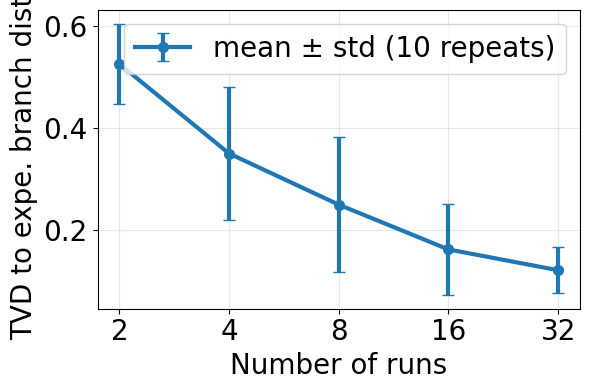

In [6]:
tele_plot_path = FIG_DIR / "validation_single_branch_teleportation_tvd_vs_n.pgf"
tele_means, tele_stds = save_tvd_plot(
    rows=tele_rows,
    N_values=N_VALUES,
    num_repeats=NUM_REPEATS,
    pgf_path=tele_plot_path,
)
print(f"Saved teleportation plot to: {tele_plot_path}")
print("Minimum state-matching fidelity over all teleportation runs:", min(r["min_match_fidelity"] for r in tele_rows))
[(N, m, s) for N, m, s in zip(N_VALUES, tele_means, tele_stds)]


## 2) Teleportation with Final Bob Measurement (8 branch states)

In [7]:
def build_dynamic_teleportation_with_bob_measurement_ir(theta, phi):
    ir = CircuitIR(no_qubits=3, no_clbits=3)

    ir.add_operation("u", [0], params=[theta, phi, 0.0])
    ir.add_operation("h", [1])
    ir.add_operation("cx", [1, 2])
    ir.add_operation("cx", [0, 1])
    ir.add_operation("h", [0])
    ir.add_operation("measure", [0], clbits=[0])
    ir.add_operation("measure", [1], clbits=[1])

    ir.add_operation("x", [2], condition={"kind": "clbit_eq", "clbit": 1, "value": 1})
    ir.add_operation("z", [2], condition={"kind": "clbit_eq", "clbit": 0, "value": 1})
    ir.add_operation("measure", [2], clbits=[2])
    return ir


def teleportation_with_bob_measurement_targets(theta, phi):
    alpha = np.cos(theta / 2.0)
    beta = np.exp(1j * phi) * np.sin(theta / 2.0)
    p2_zero = float(np.abs(alpha) ** 2)
    p2_one = float(np.abs(beta) ** 2)

    target_probs = {}
    target_states = {}

    for b0, b1, b2 in product([0, 1], repeat=3):
        p_branch = 0.25 * (p2_one if b2 == 1 else p2_zero)
        label = f"{b0}{b1}{b2}"
        target_probs[label] = float(p_branch)

        vec = np.zeros(2**3, dtype=complex)
        vec[(b0 << 2) + (b1 << 1) + b2] = 1.0
        target_states[label] = normalize_state(vec)

    return target_probs, target_states


tele_bob_ir = build_dynamic_teleportation_with_bob_measurement_ir(theta=theta, phi=phi)
tele_bob_target_probs, tele_bob_target_states = teleportation_with_bob_measurement_targets(theta=theta, phi=phi)


In [8]:
tele_bob_rows = run_convergence_experiment_by_state(
    circuit_ir=tele_bob_ir,
    target_probs=tele_bob_target_probs,
    target_states=tele_bob_target_states,
    N_values=N_VALUES,
    num_repeats=NUM_REPEATS,
    chunk_size=CHUNK_SIZE,
    no_sweeps=NO_SWEEPS,
    bond_dims=bond_dims,
    network_structure=NETWORK_STRUCTURE,
    network_type=NETWORK_TYPE,
    master_seed=2026041603,
)


Saved teleportation-with-Bob-measurement plot to: /Users/innocenzo/Desktop/Work/Quantum-Circuit-Simulator-DMRG/notebooks/figures/validation_single_branch_teleportation_bob_measure_tvd_vs_n.pgf
Minimum state-matching fidelity: 0.9999999999999998


[(2, np.float64(0.7842499999999999), np.float64(0.0449235461645672)),
 (4, np.float64(0.612), np.float64(0.07826060453524636)),
 (8, np.float64(0.40375000000000005), np.float64(0.10688291880994517)),
 (16, np.float64(0.27699999999999997), np.float64(0.0470194995010935)),
 (32, np.float64(0.153125), np.float64(0.037100885359307056))]

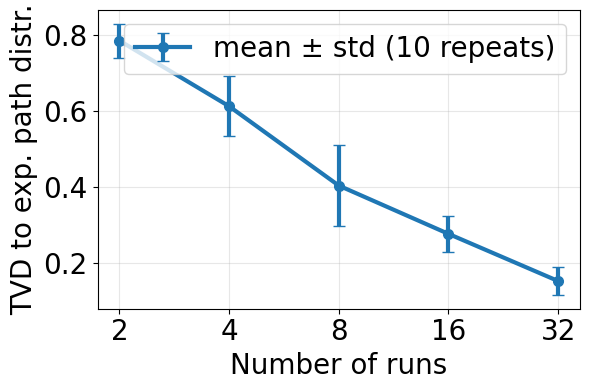

In [13]:
tele_bob_plot_path = FIG_DIR / "validation_single_branch_teleportation_bob_measure_tvd_vs_n.pgf"
tele_bob_means, tele_bob_stds = save_tvd_plot(
    rows=tele_bob_rows,
    N_values=N_VALUES,
    num_repeats=NUM_REPEATS,
    pgf_path=tele_bob_plot_path,
)
print(f"Saved teleportation-with-Bob-measurement plot to: {tele_bob_plot_path}")
print("Minimum state-matching fidelity:", min(r["min_match_fidelity"] for r in tele_bob_rows))
[(N, m, s) for N, m, s in zip(N_VALUES, tele_bob_means, tele_bob_stds)]
